# 公式チュートリアル 10 — Spatiocyte Simulations at Single-Molecule Resolution
> 出典: https://ecell4.e-cell.org/tutorials/tutorial10.html

**Spatiocyte** は格子（ボクセル）上に **1 分子ずつ**置いて拡散・反応させる単分子解像度法。粒子の軌跡を追え、
球面・平面などの**構造(structure)**上の反応も扱える。

trajectory points: 501


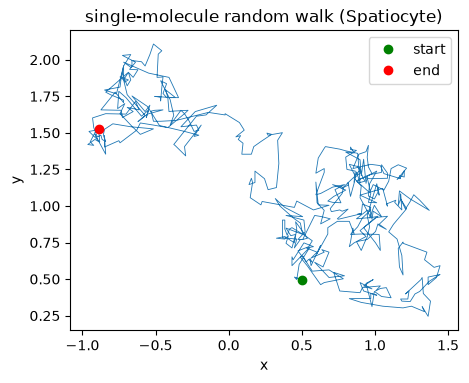

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4.prelude import *

with species_attributes():
    A | {'D': 1, 'radius': 0.005}
m = get_model()
w = spatiocyte.World(Real3(1,1,1), 0.005)   # voxel_radius = 5 nm
w.bind_to(m)
pid = w.new_particle(Species('A'), Real3(0.5, 0.5, 0.5))
pid0 = pid[0] if isinstance(pid, tuple) else pid
sim = spatiocyte.Simulator(w)
obs = FixedIntervalTrajectoryObserver(0.002, [pid0])
sim.run(1, obs)

traj = np.array([[p[0], p[1], p[2]] for p in obs.data()[0]])
print('trajectory points:', len(traj))
fig, ax = plt.subplots(figsize=(5,5))
ax.plot(traj[:,0], traj[:,1], lw=.6); ax.plot(traj[0,0], traj[0,1], 'go', label='start'); ax.plot(traj[-1,0], traj[-1,1], 'ro', label='end')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('single-molecule random walk (Spatiocyte)'); ax.legend(); ax.set_aspect('equal'); plt.show()

**要点**:
- `spatiocyte.World(edge, voxel_radius)` で格子世界を作り、`new_particle(sp, pos)` で 1 分子を置く。
- `FixedIntervalTrajectoryObserver` で 1 粒子の**軌跡**を記録（上図はランダムウォーク）。
- 構造上の反応: `A | {'location':'C', 'dimension':3}` と `w.add_structure(Species('C'), Sphere(center, r))` で
  球内に閉じ込め、`PlanarSurface(origin, unitx(), unity())` で膜（2D）上の反応も。`B + M == A` のように膜種 M を含める。

同じモデルを well-mixed → meso → Spatiocyte と解像度を上げていける（o12 の MinDE は Spatiocyte の実例）。